# **ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES**

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## **Ejercicio**

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## 0. Dependencias

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

# **1. Análisis de los datos**

## **1.1. Dimensión de los datos**

### Se carga el dataset completo para analizar los datos con los que contamos para el ejercicio.
##### Más adelante se aplica train_test_split.

In [3]:
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


### Exploramos el dataset para conocer algunas caracteristicas importantes de dimensionalidad y volumen.

In [4]:
# Exploramos el dataset
print("Número de imágenes de entrenamiento:", X.shape[0])
print("Número de imágenes de prueba:", x_test.shape[0])
print("Dimensiones de las imágenes:", X.shape[1:])
print("Número de clases:", len(np.unique(Y)))
print(f"formato de las etiquetas: {Y.shape}, ejemplo de etiqueta: {Y[0]}")


Número de imágenes de entrenamiento: 50000
Número de imágenes de prueba: 10000
Dimensiones de las imágenes: (32, 32, 3)
Número de clases: 10
formato de las etiquetas: (50000, 1), ejemplo de etiqueta: [6]


### Al tener multiples clases, es necesario revisar que se encuentren balanceadas para no introducir sesgos durante el entrenamiento.
### Se observa que las clases están muy bien balanceadas con 5000 muestras por cada clase.

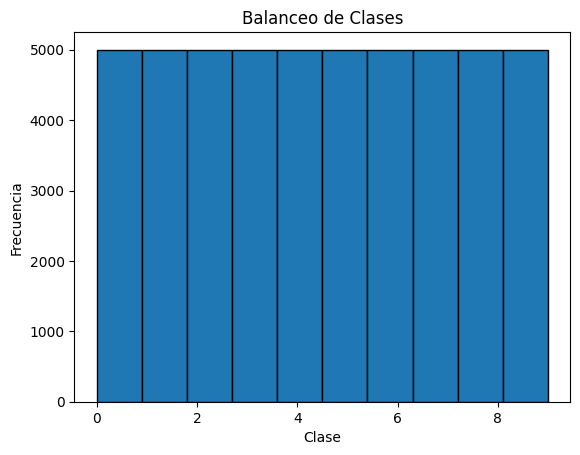

In [5]:
#mostrar el balanceo de clases
plt.hist(Y.flatten(), bins=len(np.unique(Y)), edgecolor='black')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Balanceo de Clases')
plt.show()

### Se grafica alguna de las clases del dataset. Se observa que la resolución es bastante pobre por lo que podemos anticipar que esto podria ocasionar algunos problemas durante el entrenamiento del modelo, ya que dificulta encontrar patrones relevantes.

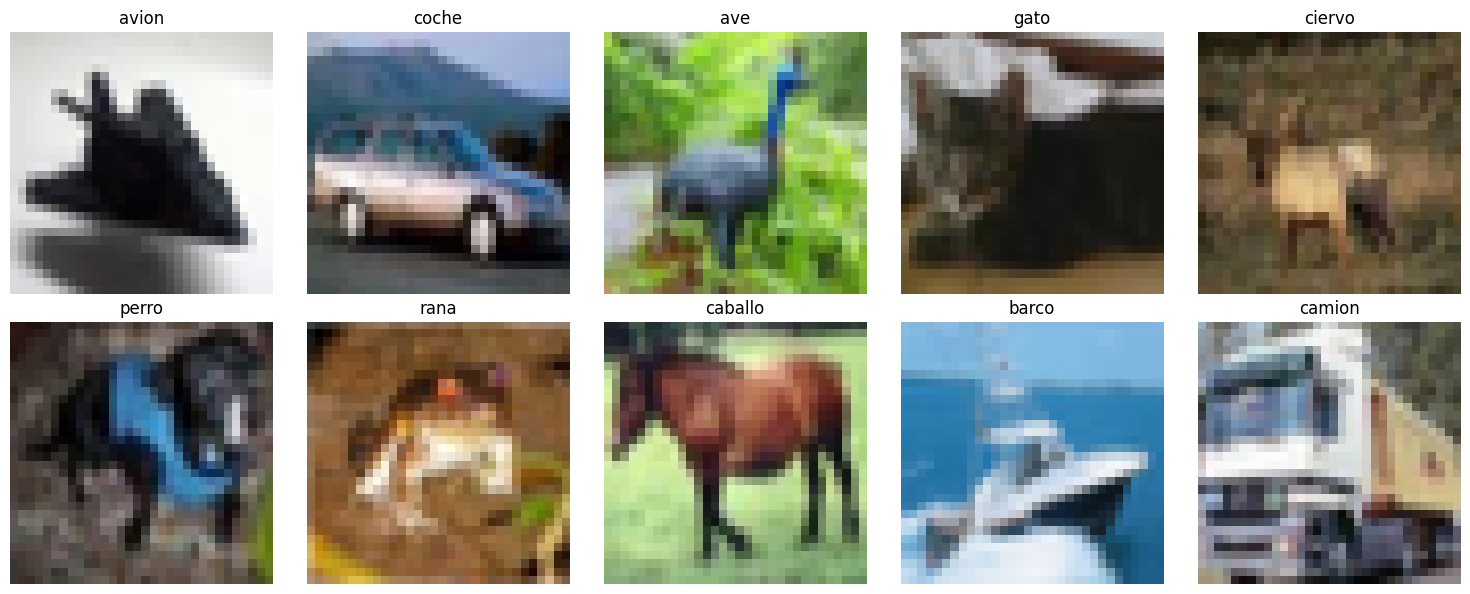

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(MAP_ELEMENTS[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

### En general, el dataset contiene un total de 50.000 muestras de 10 clases balanceadas. Las clases son imagenes de baja resolución de 32x32 pixeles. La baja resolución puede ser un punto en contra cuando entrenemos el modelo.
### La división secuencial que se realiza en esta etapa no es el apropiado porque solo se están tomando registros sin considerar el balanceo entre clase. Más adelante se deberá utilizar una partición estratificada para mantener la distribución entre clases para los conjuntos de entrenamiento, validación y test.

## **1.2. Transformación de los datos**

### Se aplican las transformaciones necesarias en los datos antes de realizar cualquier entrenamiento.

### Dividimos el dataset mediante una partición estratificada con train_test_split, para garantizar que todas las clases mantengan la misma distribución. Así reducimos posibles sesgos y mejoramos el entrenamiento del modelo.

In [7]:
(X, Y), (x_test, y_test) = cifar10.load_data()

x_train, x_valid, y_train, y_valid = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

### Siguiendo con la transformación de los datos, se procede a normalizar los valores en el rango [0,1] con el objetivo de favorecer la convergencia durante el entrenamiento

In [8]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

### Se observa que la distribución de clases es uniforme entre los conjuntos de entrenamiento, validación y test.

In [9]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print(f"x_valid shape: {x_valid.shape}")
print(f"y_valid shape: {y_valid.shape}\n")

print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

x_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 1)

x_valid shape: (10000, 32, 32, 3)
y_valid shape: (10000, 1)

x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)



### Esto confirma la partición estratificada, evitando posibles sesgos hacia determinadas clases durante el entrenamiento y evaluación de los modelos.

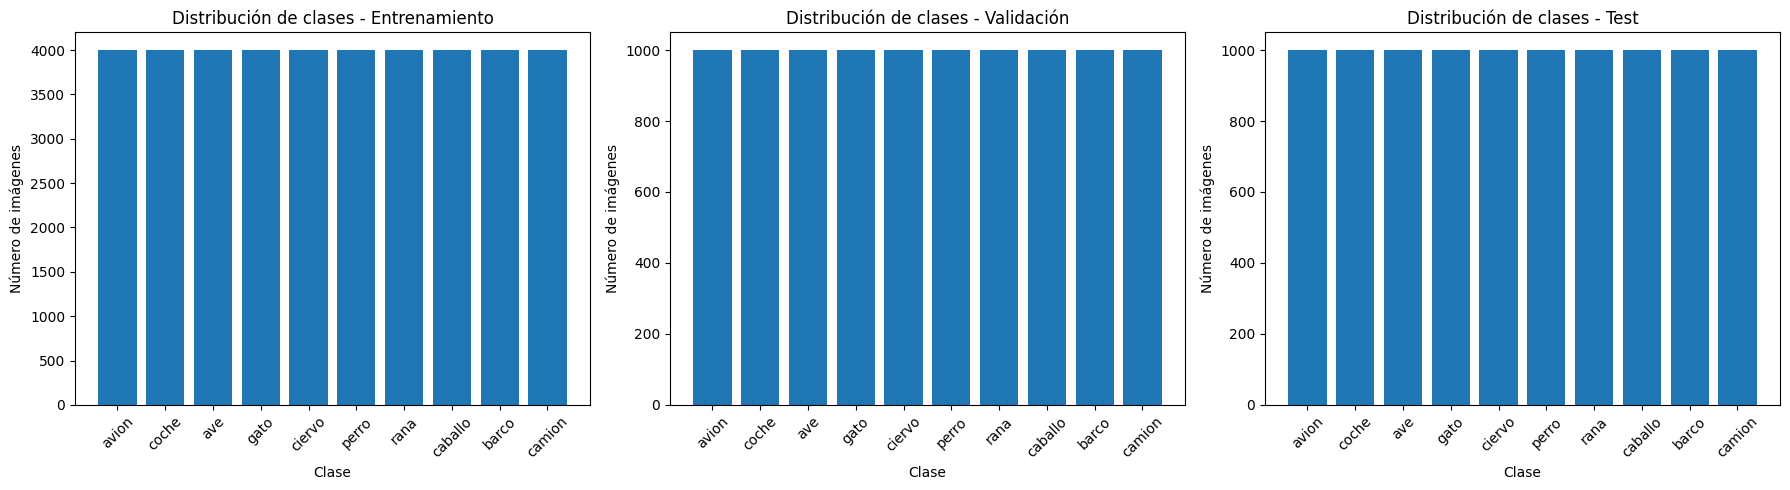

In [10]:
def count_classes(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return pd.DataFrame({
        'Clase': [MAP_ELEMENTS[i] for i in unique],
        'Cantidad': counts
    })

# Conteo de clases
train_counts = count_classes(y_train)
valid_counts = count_classes(y_valid)
test_counts  = count_classes(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ("Entrenamiento", train_counts, axes[0]),
    ("Validación", valid_counts, axes[1]),
    ("Test", test_counts, axes[2])
]

for title, df, ax in datasets:
    
    ax.bar(df["Clase"], df["Cantidad"])
    
    ax.set_title(f"Distribución de clases - {title}")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Número de imágenes")
    
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **1.3. Análisis de las imágenes**

### Las imágenes del dataset tienen una resolución de 32x32 píxeles, diferentes orientaciones, escalas, iluminación y fondos. Esto dificulta la identificación de características relevantes. Además, algunas categorías tienen similitudes importantes; en la siguiente muestra se observan similitudes entre "ciervo", "perro", "gato" y "rana".

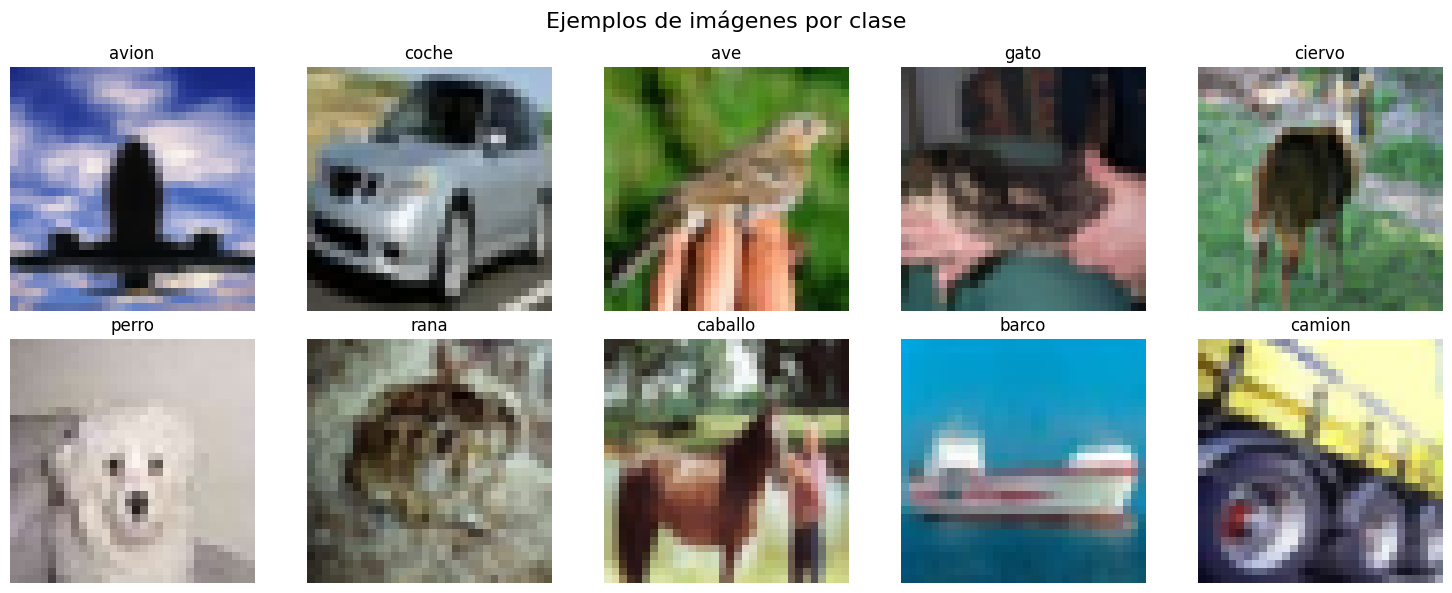

In [11]:
# Imagen por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    
    # Buscar primera imagen de la clase i
    idx = np.where(y_train.flatten() == i)[0][0]
    
    ax.imshow(x_train[idx])
    ax.set_title(MAP_ELEMENTS[i])
    ax.axis("off")

plt.suptitle("Ejemplos de imágenes por clase", fontsize=16)
plt.tight_layout()
plt.show()

### También tenemos variabilidad intra-clase; los objetos pueden aparecer en distintas posiciones, escalas y contextos. Debido a estas variaciones, se necesitan modelos capaces de capturar patrones espaciales locales y jerárquicos. Aquí es donde entran las redes convolucionales.

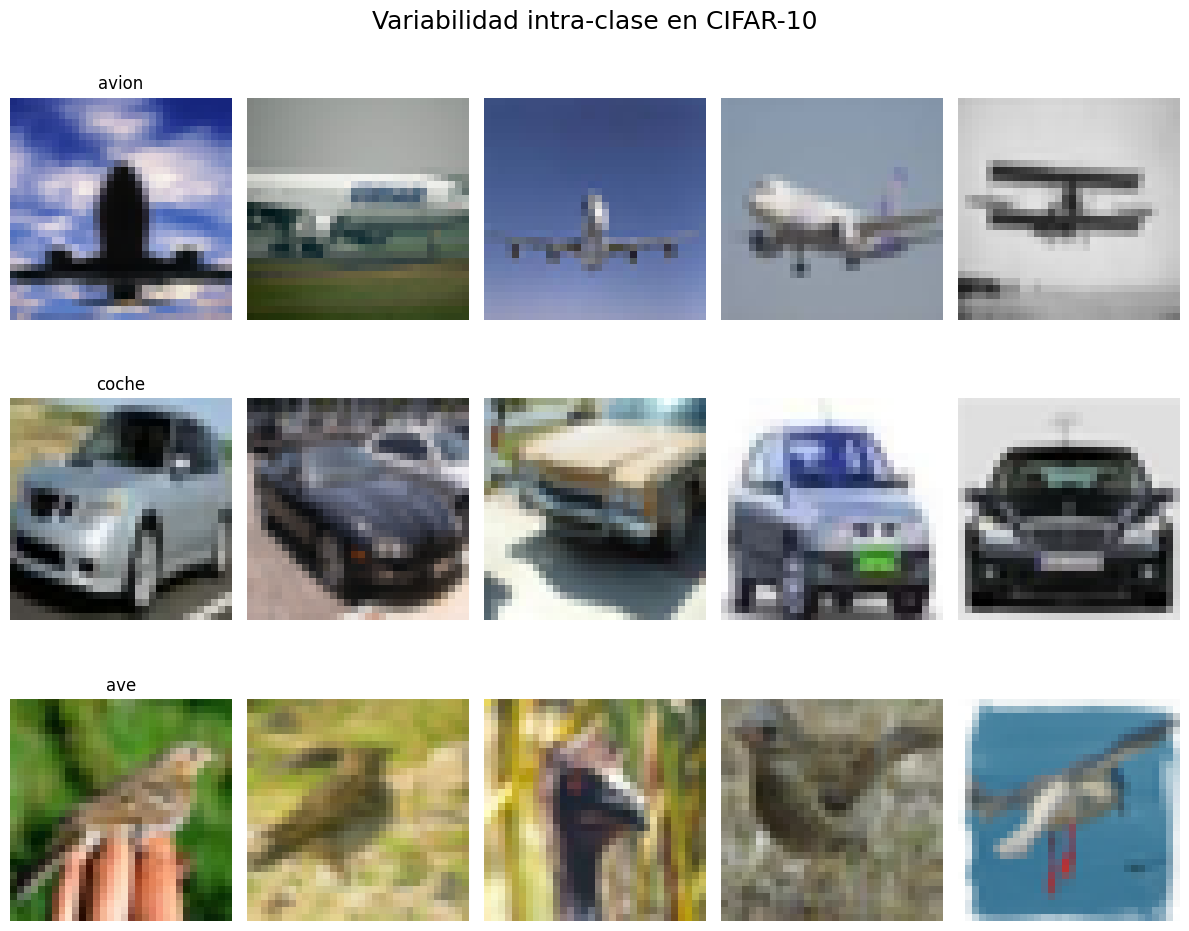

In [12]:
# Variabilidad intra-clase
fig, axes = plt.subplots(3, 5, figsize=(12, 10))

for class_id in range(3):
    
    # Obtener índices de imágenes de la clase
    idxs = np.where(y_train.flatten() == class_id)[0][:5]
    
    for j, idx in enumerate(idxs):
        
        axes[class_id, j].imshow(x_train[idx])
        axes[class_id, j].axis("off")
        
        if j == 0:
            axes[class_id, j].set_title(MAP_ELEMENTS[class_id])

plt.suptitle("Variabilidad intra-clase en CIFAR-10", fontsize=18)
plt.tight_layout()
plt.show()

# **2. Red básica fully connected**

## **2.1. Dimensión de los datos**

### Las redes fully connected requieren vectores unidimensionales como entrada. Por este motivo, las imágenes RGB de tamaño 32x32x3 fueron transformadas en vectores de 3072 características mediante una operación de flattening.

### Tras aplicar flattening, cada imagen queda representada mediante un vector de 3072 valores. Aunque esta transformación permite utilizar capas densas tradicionales, también implica la pérdida de la estructura espacial de la imagen.

### Esto previsiblemente limitará la capacidad del modelo para reconocer patrones visuales complejos, permitiendo posteriormente comparar las limitaciones de las redes densas frente a las arquitecturas convolucionales.

In [13]:
# Guardamos dimensiones originales
input_shape = x_train.shape[1:]

print("Forma original de las imágenes:", input_shape)

# Flatten de las imágenes
x_train_fc = x_train.reshape(x_train.shape[0], -1)
x_valid_fc = x_valid.reshape(x_valid.shape[0], -1)
x_test_fc  = x_test.reshape(x_test.shape[0], -1)

# Verificación de dimensiones
print(f"Entrenamiento dimensiones: {x_train_fc.shape}")
print(f"Validación dimensiones: {x_valid_fc.shape}")
print(f"Test dimensiones: {x_test_fc.shape}")

Forma original de las imágenes: (32, 32, 3)
Entrenamiento dimensiones: (40000, 3072)
Validación dimensiones: (10000, 3072)
Test dimensiones: (10000, 3072)


### Comprobamos que la primera imagen es un vector

In [14]:
print(x_train_fc[0][:10])

[0.21960784 0.19607843 0.16470588 0.23137255 0.2        0.16078431
 0.2745098  0.25490196 0.2        0.37647059]


## **2.2. Definición y entrenamiento del modelo**

### Como baseline inicial se implementó una red neuronal fully connected compuesta por dos capas densas ocultas y una capa de salida Softmax.

### La función de activación ReLU se utilizó en las capas ocultas debido a su buen comportamiento en Deep Learning, mientras que la capa Softmax permite obtener probabilidades asociadas a cada una de las 10 clases.

### Este modelo servirá como referencia inicial para posteriormente comparar el impacto de las capas convolucionales sobre el rendimiento del clasificador.

### El elevado número de parámetros es por el tamaño del vectores de entrada de tamaño 3072.

### El modelo fully connected es entrenado utilizando el optimizador Adam y la función de pérdida categorical crossentropy, adecuada para problemas de clasificación multiclase.


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Definición del modelo
baseline_model = Sequential([
    
    Dense(512, activation='relu', input_shape=(3072,)),
    
    Dense(256, activation='relu'),
    
    Dense(10, activation='softmax')
])

# Compilación del modelo
baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
baseline_model.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### Se utilizaron 15 épocas y un tamaño de batch de 64 muestras. Durante el entrenamiento se monitorizó el rendimiento tanto sobre entrenamiento como sobre validación, con el objetivo de analizar posibles fenómenos de overfitting.

### El modelo muestra una mejora progresiva del accuracy sobre entrenamiento durante las primeras épocas. Sin embargo, la curva de validación comienza a estabilizarse antes que la de entrenamiento, indicando la aparición de cierto sobreajuste. Este comportamiento es esperable en arquitecturas fully connected aplicadas a imágenes complejas como CIFAR-10.

In [16]:
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot  = convert_to_one_hot(y_test, num_classes)

history_baseline = baseline_model.fit(
    
    x_train_fc,
    y_train_one_hot,
    
    validation_data=(x_valid_fc, y_valid_one_hot),
    
    epochs=15,
    batch_size=64,
    
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3231 - loss: 1.8825 - val_accuracy: 0.3660 - val_loss: 1.7624
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3883 - loss: 1.6985 - val_accuracy: 0.4091 - val_loss: 1.6550
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4265 - loss: 1.6078 - val_accuracy: 0.4154 - val_loss: 1.6270
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4425 - loss: 1.5567 - val_accuracy: 0.4414 - val_loss: 1.5683
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4608 - loss: 1.5095 - val_accuracy: 0.4512 - val_loss: 1.5447
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4729 - loss: 1.4698 - val_accuracy: 0.4574 - val_loss: 1.5305
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4844 - loss: 1.4434 - val_accuracy: 0.4580 - val_loss: 1.5367
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4956 - loss: 1.4134 - val_accuracy: 0.

## **2.3. Análisis de resultados**

### El modelo fully connected alcanza aproximadamente un 50% de accuracy sobre el conjunto de validación. Aunque el modelo es capaz de aprender patrones relevantes, el rendimiento resulta limitado para un problema visual complejo como CIFAR-10.

### La diferencia entre el accuracy de entrenamiento y validación sugiere la aparición de cierto sobreajuste, indicando que la arquitectura fully connected presenta dificultades para generalizar correctamente en este tipo de imágenes.

### Además, la curva de validación tiende a estabilizarse a partir de las últimas épocas, mientras que el entrenamiento continúa mejorando reforzando la evidencia de overfitting.

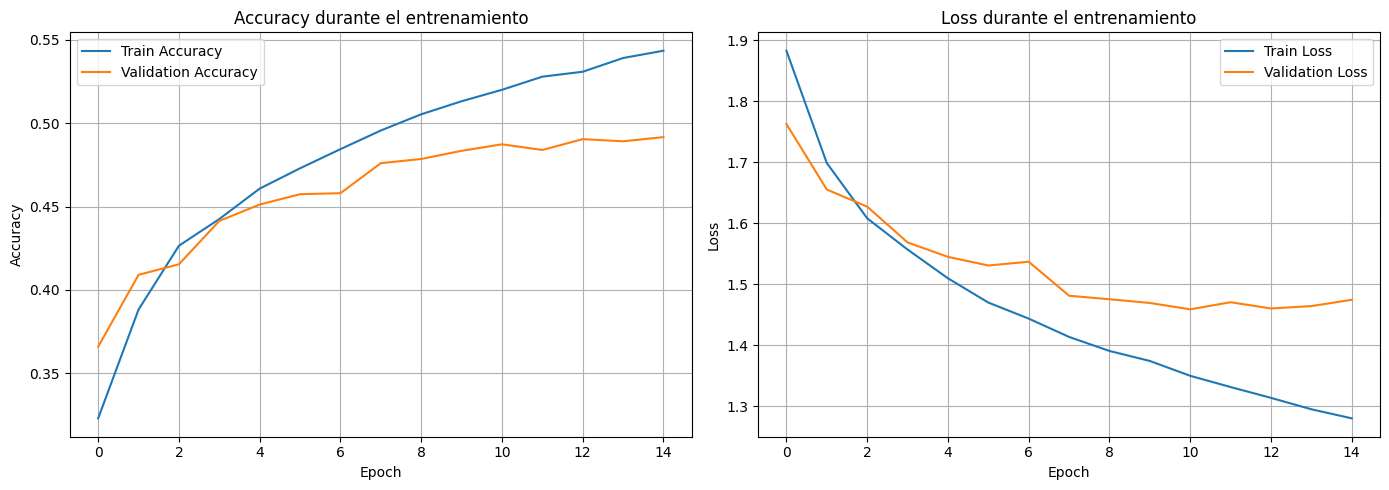

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_baseline.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

ax[0].set_title('Accuracy durante el entrenamiento')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')

ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_baseline.history['loss'], label='Train Loss')
ax[1].plot(history_baseline.history['val_loss'], label='Validation Loss')

ax[1].set_title('Loss durante el entrenamiento')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
test_loss, test_accuracy = baseline_model.evaluate(
    x_test_fc,
    y_test_one_hot,
    verbose=0
)

# Crear tabla resumen
results_df = pd.DataFrame({
    'Métrica': ['Test Loss', 'Test Accuracy'],
    'Valor': [test_loss, test_accuracy]
})

# Mostrar tabla
results_df


,Métrica,Valor
0,Test Loss,1.458485
1,Test Accuracy,0.487900


### Las clases con mejor rendimiento son "avión", "barco" y "coche", mientras que algunas de las clases con peor rendimiento son "gato", "perro" y "ciervo".

### Esto puede explicarse porque muchas clases de animales comparten patrones visuales similares, dificultando la diferenciación para una arquitectura fully connected. Además, al utilizar flattening se pierde la estructura espacial de la imagen, limitando aún más la capacidad del modelo para distinguir características visuales complejas.

In [28]:
from sklearn.metrics import classification_report

# Predicciones
y_pred_probs = baseline_model.predict(x_test_fc)

# Clase predicha
y_pred = np.argmax(y_pred_probs, axis=1)

# Clases reales
y_true = y_test.flatten()

# Reporte
report = classification_report(
    y_true,
    y_pred,
    target_names=[MAP_ELEMENTS[i] for i in range(10)]
)

print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

       avion       0.58      0.54      0.56      1000
       coche       0.52      0.68      0.59      1000
         ave       0.34      0.50      0.40      1000
        gato       0.39      0.17      0.24      1000
      ciervo       0.44      0.39      0.41      1000
       perro       0.44      0.40      0.42      1000
        rana       0.47      0.60      0.53      1000
     caballo       0.64      0.45      0.53      1000
       barco       0.60      0.64      0.62      1000
      camion       0.51      0.51      0.51      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



### La matriz de confusión muestra que el modelo presenta mayores dificultades para distinguir clases visualmente similares, especialmente entre animales como "gato", "perro", "ciervo". También se observan confusiones entre clases de vehículos como "coche" y "camión".

### Esto evidencia las limitaciones de las redes fully connected para capturar patrones espaciales complejos en imágenes, debido a la pérdida de información espacial producida por la operación de flattening.

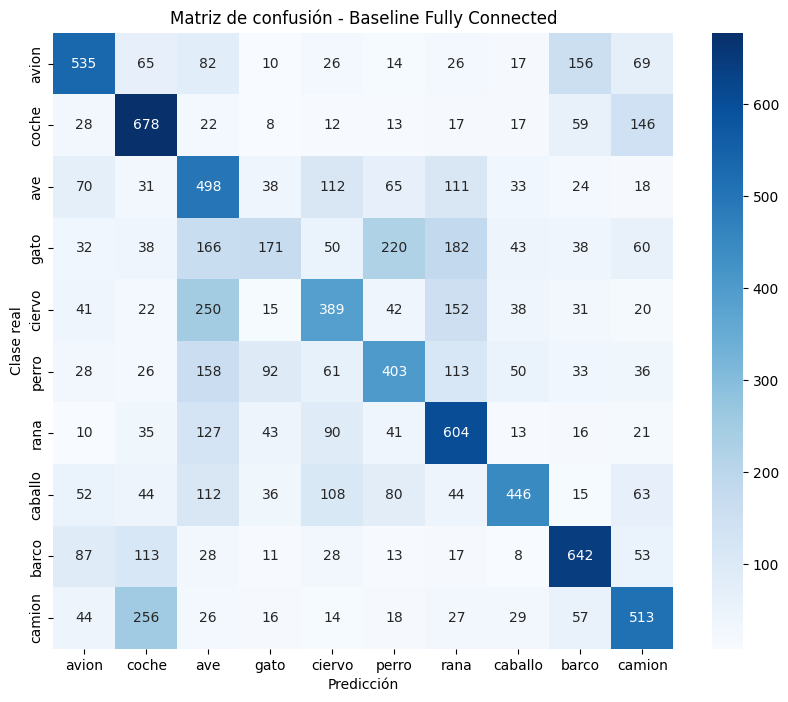

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[MAP_ELEMENTS[i] for i in range(10)],
    yticklabels=[MAP_ELEMENTS[i] for i in range(10)]
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - Baseline Fully Connected")

plt.show()

### Muchas de las imágenes mal clasificadas presentan baja resolución, objetos parcialmente visibles o similitudes importantes entre categorías. Esto dificulta que una arquitectura fully connected pueda extraer características fuertemente diferenciales.

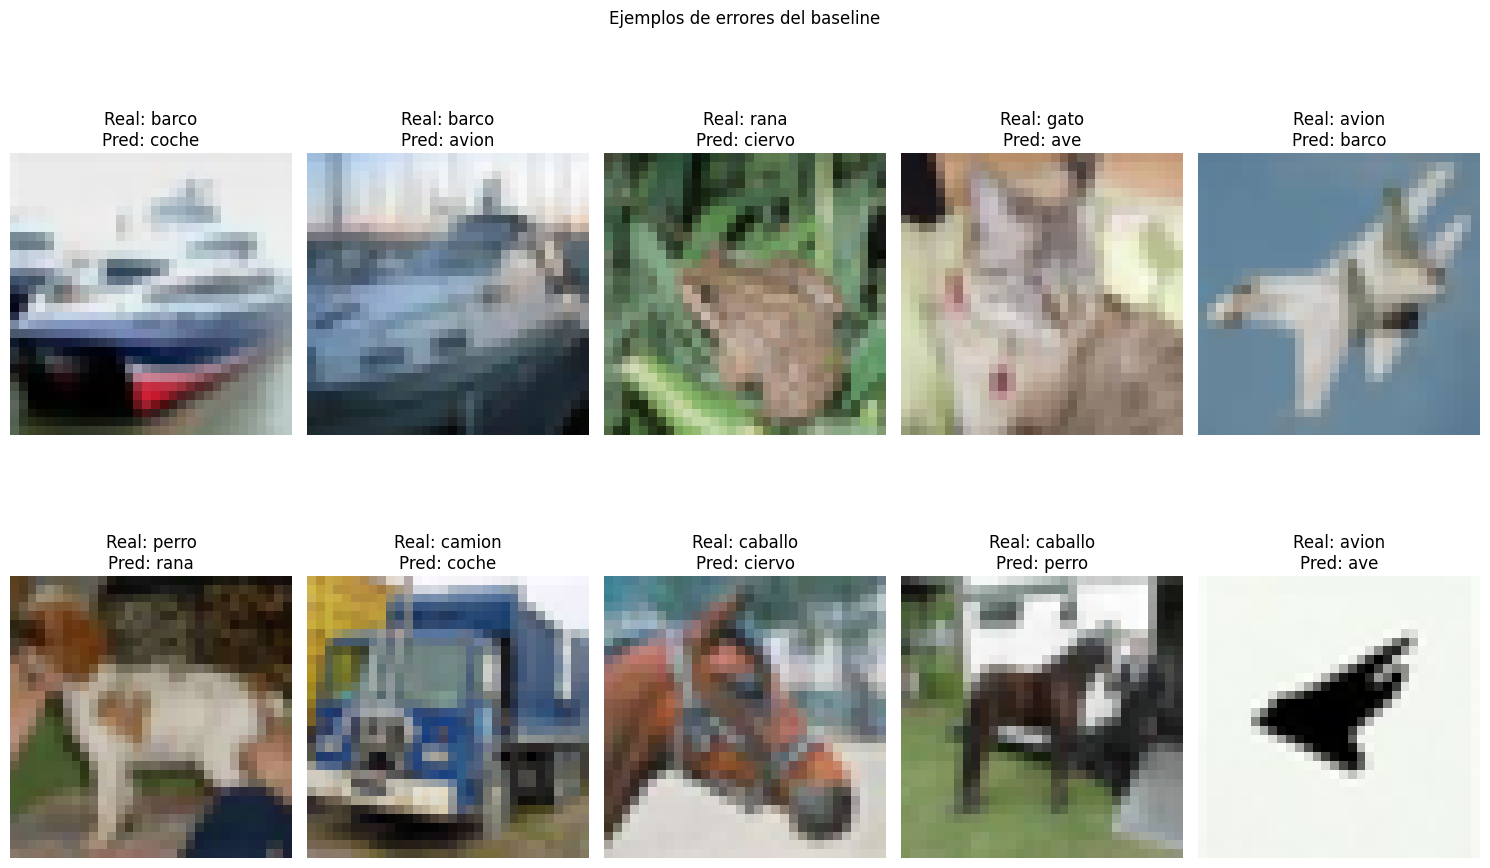

In [30]:
errors = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors[:10]):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(x_test[idx])
    
    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred[idx]]
    
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    
    plt.axis("off")

plt.suptitle("Ejemplos de errores del baseline")
plt.tight_layout()

plt.show()

## **3. CNN Base**

## **3.1. Dimensión de los datos**

### A diferencia del modelo fully connected, las redes convolucionales trabajan directamente sobre la estructura bidimensional de las imágenes. En esta fase no se aplica flattening sobre los datos de entrada preservando las relaciones espaciales entre píxeles vecinos.

### Las imágenes mantienen su representación original de 32x32 píxeles y 3 canales RGB, permitiendo que la red convolucional pueda explotar información espacial local mediante filtros convolucionales.


In [32]:
print("Forma de entrada de los datos para CNN:")

print(f"Dimensiones de entrenamiento: {x_train.shape}")
print(f"Dimensiones de validación: {x_valid.shape}")
print(f"Dimensiones de prueba: {x_test.shape}")

Forma de entrada de los datos para CNN:
Dimensiones de entrenamiento: (40000, 32, 32, 3)
Dimensiones de validación: (10000, 32, 32, 3)
Dimensiones de prueba: (10000, 32, 32, 3)


## **3.2. Definición y entrenamiento del modelo**

### Las capas convolucionales permiten extraer características espaciales mediante filtros, manteniendo la estructura espacial de las imágenes.

### Las capas MaxPooling reducen progresivamente la dimensionalidad espacial de las representaciones internas, disminuyendo el número de parámetros y favoreciendo la extracción de características relevantes.

### Esto permite observar que las convoluciones sí marcan una diferencia importante frente a las arquitecturas fully connected.

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)
from tensorflow.keras.optimizers import Adam

# Definición de la CNN
cnn_model = Sequential([

    # Primera capa convolucional
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Segunda capa convolucional
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Conversión a vector
    Flatten(),

    # Capa densa
    Dense(128, activation='relu'),

    # Capa de salida
    Dense(10, activation='softmax')
])

# Compilación
cnn_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
cnn_model.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

### Se mantienen condiciones comparables para aislar el efecto de las convoluciones.

| Elemento   | Valor                    |
| ---------- | ------------------------ |
| optimizer  | Adam                     |
| epochs     | 15                       |
| batch_size | 64                       |
| loss       | categorical_crossentropy |

### La mejora observada proviene fundamentalmente de la arquitectura CNN.

### La primera red convolucional fue entrenada utilizando la misma configuración en el fully connected, con el objetivo de realizar una comparación justa entre arquitecturas.

### Se utilizó el optimizador Adam, la función de pérdida categorical crossentropy, 15 épocas y batches de 64 muestras.

In [35]:
history_cnn = cnn_model.fit(

    x_train,
    y_train_one_hot,

    validation_data=(x_valid, y_valid_one_hot),

    epochs=15,
    batch_size=64,

    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4514 - loss: 1.5281 - val_accuracy: 0.5489 - val_loss: 1.2827
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5849 - loss: 1.1732 - val_accuracy: 0.5979 - val_loss: 1.1493
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6400 - loss: 1.0311 - val_accuracy: 0.6436 - val_loss: 1.0283
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6723 - loss: 0.9367 - val_accuracy: 0.6554 - val_loss: 0.9965
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7030 - loss: 0.8591 - val_accuracy: 0.6633 - val_loss: 0.9756
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7250 - loss: 0.7873 - val_accuracy: 0.6756 - val_loss: 0.9452
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7484 - loss: 0.7231 - val_accuracy: 0.6794 - val_loss: 0.9520
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7690 - loss: 0.6631 - val_accuracy: 

## **3.3. Análisis de resultados**

### A diferencia del fully connected, la CNN muestra una mejora tanto en entrenamiento como en validación. La arquitectura convolucional captura patrones espaciales relevantes y permite una representación más eficiente de las imágenes y una mejor capacidad de generalización.

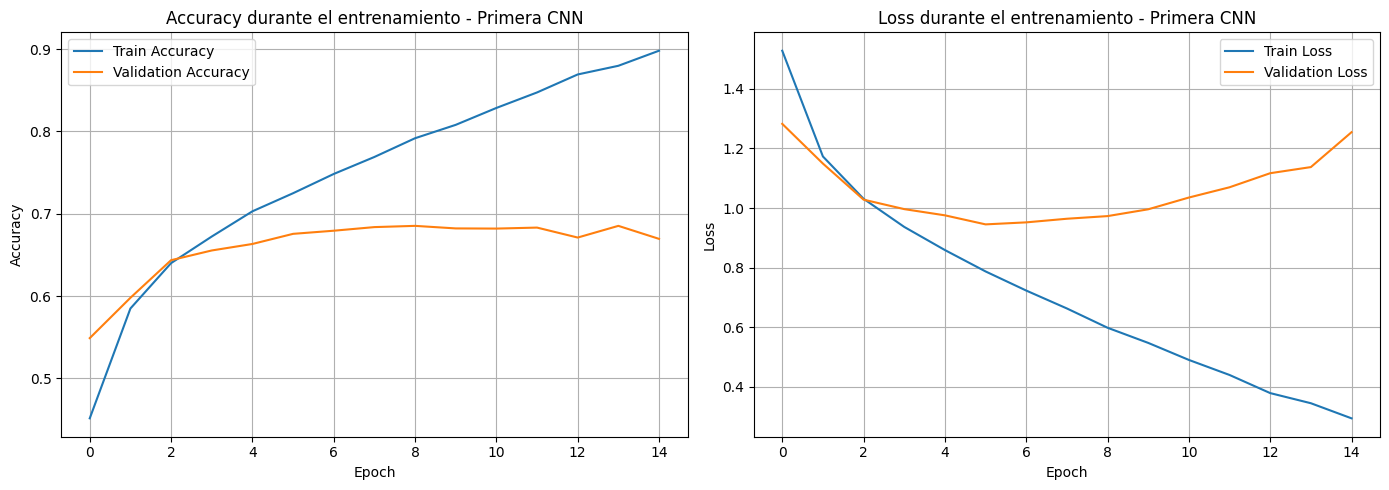

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_cnn.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

ax[0].set_title('Accuracy durante el entrenamiento - Primera CNN')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')

ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_cnn.history['loss'], label='Train Loss')
ax[1].plot(history_cnn.history['val_loss'], label='Validation Loss')

ax[1].set_title('Loss durante el entrenamiento - Primera CNN')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### La CNN obtiene una mejora muy significativa respecto al baseline fully connected, alcanzando 66% de accuracy sobre el conjunto de test.

### Este resultado evidencia una mejora en la capacidad de las redes convolucionales para extraer patrones espaciales relevantes y generalizar mejor en tareas de visión artificial.

In [40]:
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(
    x_test,
    y_test_one_hot,
    verbose=0
)

# Crear tabla resumen
results_df = pd.DataFrame({
    'Métrica': ['Test Loss', 'Test Accuracy'],
    'Valor': [test_loss_cnn, test_accuracy_cnn]
})

results_df

,Métrica,Valor
0,Test Loss,1.280468
1,Test Accuracy,0.662600


### El classification report muestra una mejora generalizada en prácticamente todas las clases respecto al modelo fully connected. Las categorías con patrones visuales más complejos, como animales, se benefician de la capacidad de las convoluciones para capturar características espaciales.

In [ ]:
from sklearn.metrics import classification_report

# Predicciones
y_pred_probs_cnn = cnn_model.predict(x_test)

# Clase predicha
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# Clases reales
y_true = y_test.flatten()

# Reporte
report_cnn = classification_report(
    y_true,
    y_pred_cnn,
    target_names=[MAP_ELEMENTS[i] for i in range(10)]
)

print(report_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

       avion       0.66      0.71      0.68      1000
       coche       0.83      0.75      0.79      1000
         ave       0.51      0.58      0.54      1000
        gato       0.43      0.56      0.49      1000
      ciervo       0.65      0.61      0.63      1000
       perro       0.62      0.47      0.54      1000
        rana       0.72      0.79      0.75      1000
     caballo       0.80      0.65      0.72      1000
       barco       0.74      0.81      0.77      1000
      camion       0.79      0.70      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



### La matriz de confusión muestra una mejora respecto al baseline fully connected. Sin embargo, siguen existiendo confusiones entre clases visualmente similares, sobre todo entre ciertos animales como "gato", "perro", "ciervo" y "ave".

### También se observa una mejora importante en clases como "camión", "barco", "coche" y "rana", donde la red logra identificar mejor los patrones y tiene una tasa de aciertos superior.

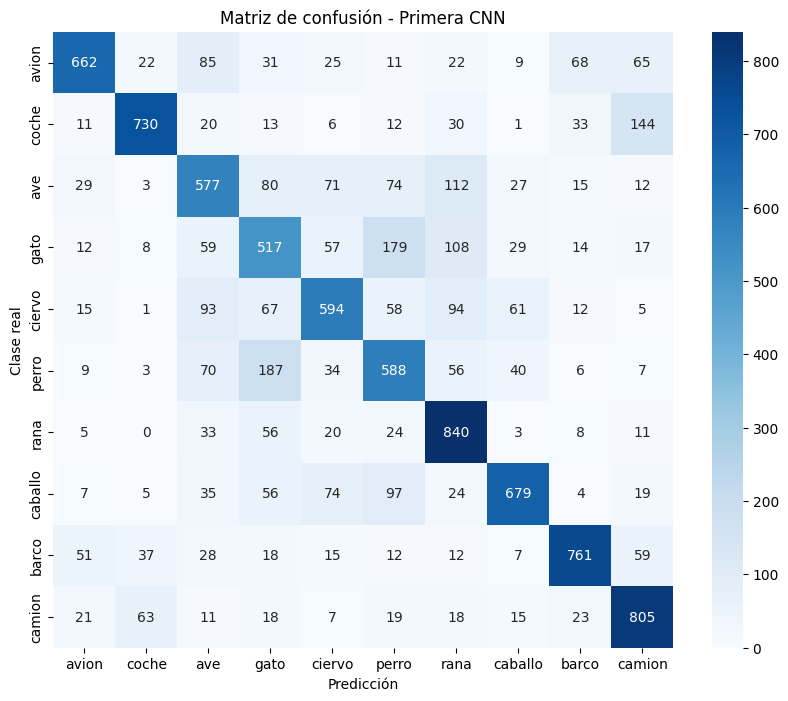

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[MAP_ELEMENTS[i] for i in range(10)],
    yticklabels=[MAP_ELEMENTS[i] for i in range(10)]
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")

plt.title("Matriz de confusión - Primera CNN")

plt.show()

### Muchas de las imágenes incorrectamente clasificadas presentan ambigüedad visual, baja resolución o similitudes importantes entre clases. A pesar de la mejora respecto al baseline fully connected, ciertas categorías siguen resultando difíciles incluso para la CNN básica.

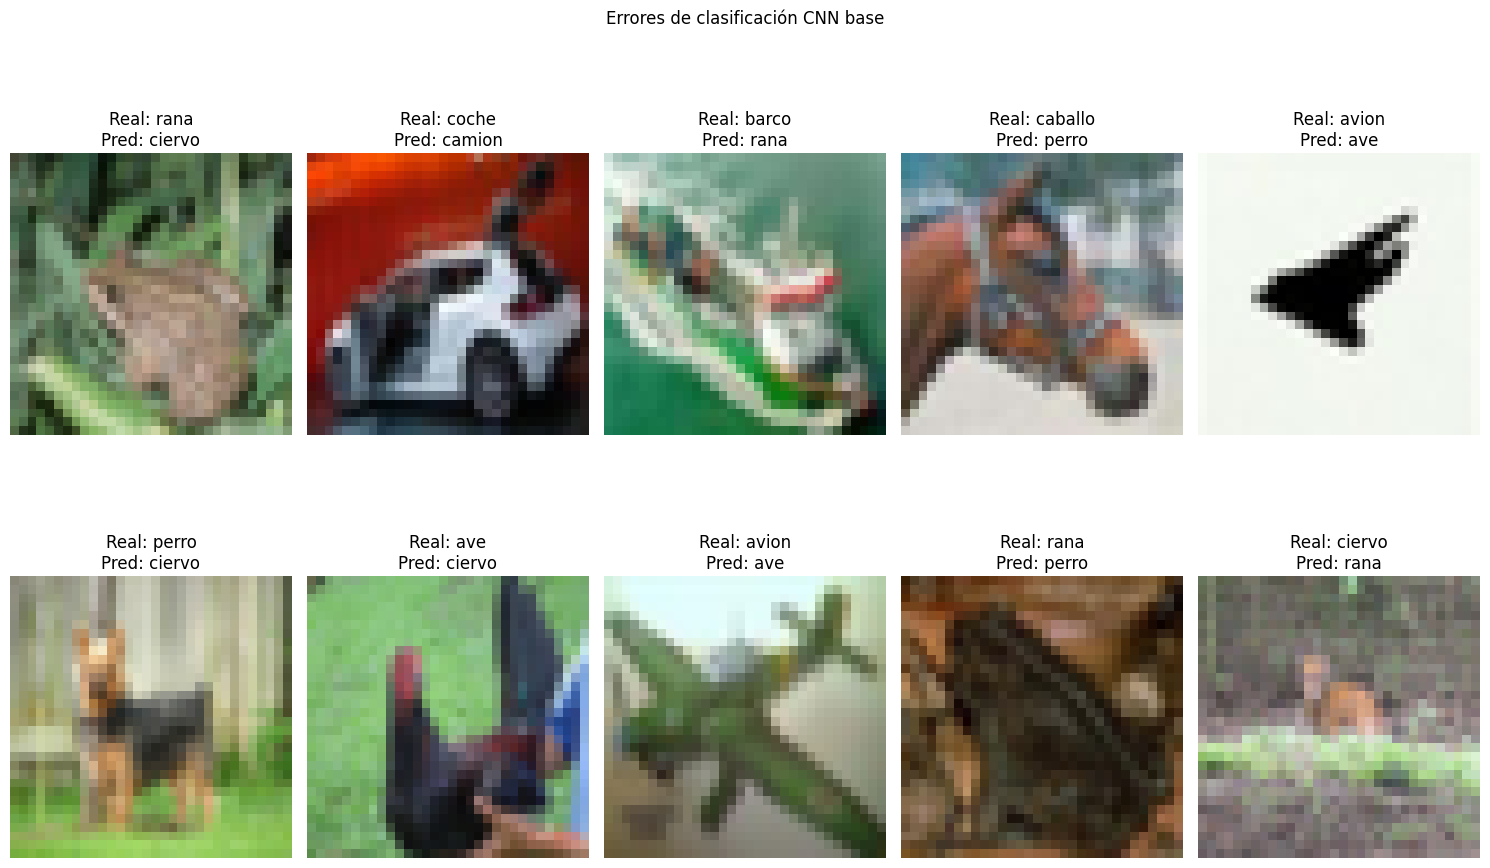

In [67]:
errors_cnn = np.where(y_pred_cnn != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors_cnn[:10]):
    
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx])

    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred_cnn[idx]]

    plt.title(f"Real: {true_label}\nPred: {pred_label}")

    plt.axis("off")

plt.suptitle("Errores de clasificación CNN base")

plt.tight_layout()

plt.show()

### La CNN supera al modelo fully connected en de capacidad de generalización y precisión sobre el conjunto de test.

### Esto confirma que las arquitecturas convolucionales son mucho más adecuadas para problemas de clasificación de imágenes, ya que preservan la estructura espacial y permiten aprender representaciones jerárquicas de los patrones visuales.

### En comparación con el baseline fully connected, la CNN incrementa el accuracy sobre test desde aproximadamente 48% hasta 66%, evidenciando el impacto de las convoluciones en tareas de visión artificial.

In [45]:

comparison = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "CNN Base"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_cnn
    ]
})

comparison

,Modelo,Test Accuracy
0,Fully Connected,0.4879
1,CNN Base,0.6626


## **4. CNN Regularización y Batch Normalization**

## **4.1. Dimensión de los datos**

### La dimensionalidad de los datos se mantiene sin cambios respecto a la CNN base. Las imágenes conservan su representación original de 32x32 píxeles y 3 canales RGB.

### En esta fase, se abordan técnicas de regularización y estabilización del entrenamiento, sin modificar la forma de entrada de los datos.

## **4.2. Definición y entrenamiento del modelo**

### Batch Normalization normaliza las activaciones internas de la red con el objetivo de estabilizar el entrenamiento, acelerar la convergencia y reducir la sensibilidad a la inicialización de pesos. Ayuda a mantener distribuciones internas más estables durante el entrenamiento.

### Esta arquitectura mantiene la estructura de la CNN básica, pero incorpora mecanismos de regularización y estabilización del entrenamiento mediante Dropout y Batch Normalization. Esto permite evaluar experimentalmente el impacto de estas técnicas sobre la capacidad de generalización del modelo.

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

model_cnn_reg = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.2),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu'),

    BatchNormalization(),

    Dropout(0.3),

    Dense(10, activation='softmax')
])


model_cnn_reg.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_reg.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,994 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 448 (1.75 KB)

### El modelo fue entrenado utilizando la misma configuración experimental de la CNN base, incorporando ahora técnicas de regularización y estabilización mediante Dropout y Batch Normalization para mejorar la capacidad de generalización.

In [60]:
history_cnn_reg = model_cnn_reg.fit(
    x_train,
    y_train_one_hot,
    epochs=15,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4380 - loss: 1.6511 - val_accuracy: 0.4857 - val_loss: 1.4789
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5778 - loss: 1.2015 - val_accuracy: 0.6133 - val_loss: 1.1012
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6305 - loss: 1.0478 - val_accuracy: 0.6279 - val_loss: 1.0780
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6627 - loss: 0.9620 - val_accuracy: 0.6668 - val_loss: 0.9371
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6862 - loss: 0.8934 - val_accuracy: 0.6603 - val_loss: 0.9615
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7056 - loss: 0.8437 - val_accuracy: 0.6950 - val_loss: 0.8722
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7189 - loss: 0.8011 - val_accuracy: 0.6771 - val_loss: 0.9525
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7311 - loss: 0.7638 - 

## **4.3. Análisis de resultados**

### Esta CNN presenta curvas de entrenamiento y validación con mejor capacidad de generalización y una reducción del sobreajuste.

### Batch Normalization contribuye a estabilizar el entrenamiento y acelerar la convergencia, mientras que Dropout ayuda a reducir la dependencia excesiva entre neuronas. Como resultado, el modelo logra un comportamiento más robusto sobre datos no vistos.

### Aunque existen pequeñas fluctuaciones en validación, las métricas muestran un comportamiento considerablemente más robusto gracias a la incorporación de Batch Normalization y Dropout.

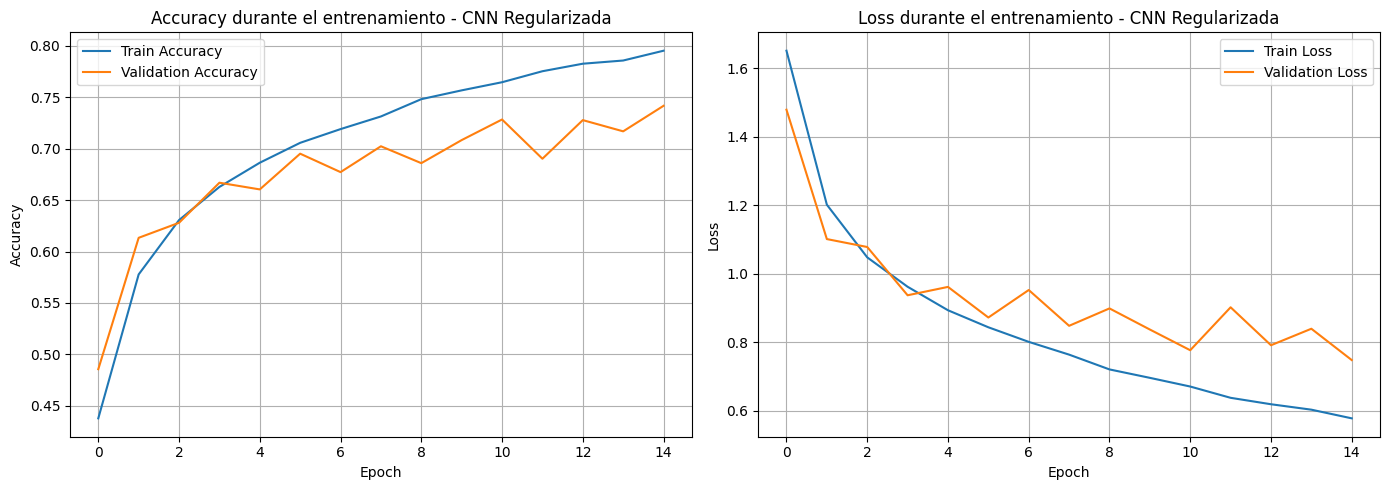

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_cnn_reg.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_cnn_reg.history['val_accuracy'], label='Validation Accuracy')

ax[0].set_title('Accuracy durante el entrenamiento - CNN Regularizada')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')

ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_cnn_reg.history['loss'], label='Train Loss')
ax[1].plot(history_cnn_reg.history['val_loss'], label='Validation Loss')

ax[1].set_title('Loss durante el entrenamiento - CNN Regularizada')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### La CNN regularizada alcanza aproximadamente un 75% de accuracy sobre el conjunto de test, obteniendo el mejor rendimiento entre las arquitecturas evaluadas.


In [71]:
test_loss_cnn_reg, test_accuracy_cnn_reg = model_cnn_reg.evaluate(
    x_test,
    y_test_one_hot,
    verbose=0
)

# Tabla resumen
results_cnn_reg_df = pd.DataFrame({
    'Métrica': ['Test Loss', 'Test Accuracy'],
    'Valor': [test_loss_cnn_reg, test_accuracy_cnn_reg]
})

results_cnn_reg_df

,Métrica,Valor
0,Test Loss,0.749337
1,Test Accuracy,0.748100


### El reporte muestra una mejora general del rendimiento respecto a la CNN básica.

### La incorporación de Batch Normalization y Dropout permite obtener representaciones más robustas y reducir el sobreajuste, mejorando la capacidad del modelo para clasificar correctamente imágenes no vistas.

### Aunque todavía existen confusiones entre clases visualmente similares, especialmente entre algunos animales, el modelo regularizado presenta un comportamiento más estable y equilibrado entre las distintas categorías.

In [63]:
from sklearn.metrics import classification_report
import numpy as np

# Predicciones del modelo
y_pred_probs = model_cnn_reg.predict(x_test)

# Convertir probabilidades a clases
y_pred = np.argmax(y_pred_probs, axis=1)

# Convertir etiquetas one-hot a clases
y_true = np.argmax(y_test_one_hot, axis=1)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=MAP_ELEMENTS.values()
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

       avion       0.73      0.83      0.78      1000
       coche       0.91      0.81      0.85      1000
         ave       0.69      0.62      0.65      1000
        gato       0.54      0.62      0.58      1000
      ciervo       0.68      0.71      0.70      1000
       perro       0.68      0.60      0.64      1000
        rana       0.75      0.87      0.81      1000
     caballo       0.88      0.73      0.80      1000
       barco       0.85      0.85      0.85      1000
      camion       0.82      0.84      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



### La matriz de confusión muestra un comportamiento más estable y una mejor capacidad de generalización respecto a las arquitecturas anteriores.

### Aunque todavía existen confusiones entre clases, la CNN regularizada logra capturar patrones discriminativos más robustos gracias a la incorporación de Batch Normalization y Dropout.


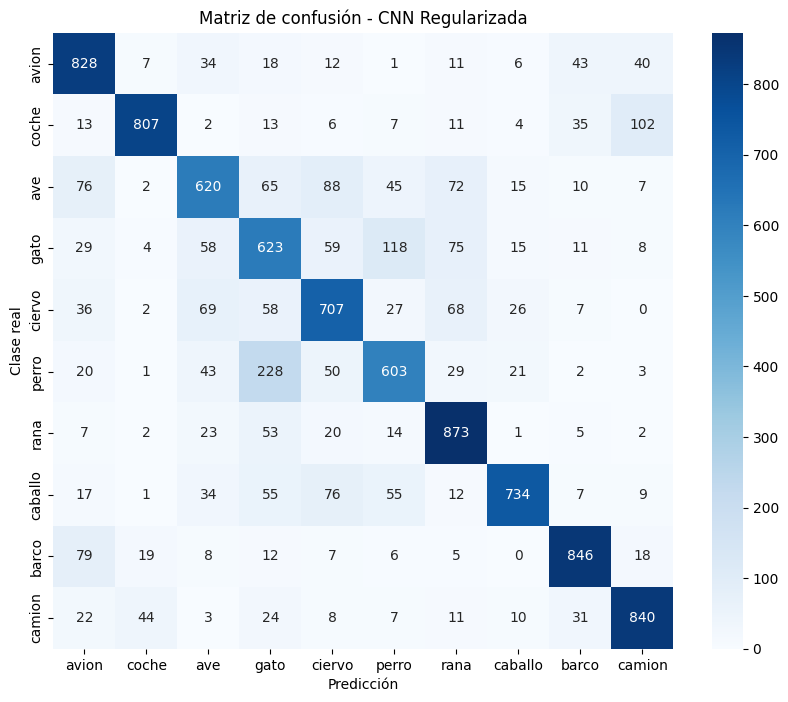

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualización
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=MAP_ELEMENTS.values(),
    yticklabels=MAP_ELEMENTS.values()
)

plt.title('Matriz de confusión - CNN Regularizada')

plt.xlabel('Predicción')
plt.ylabel('Clase real')

plt.show()

### Ejemplo de imágenes incorrectamente clasificadas.

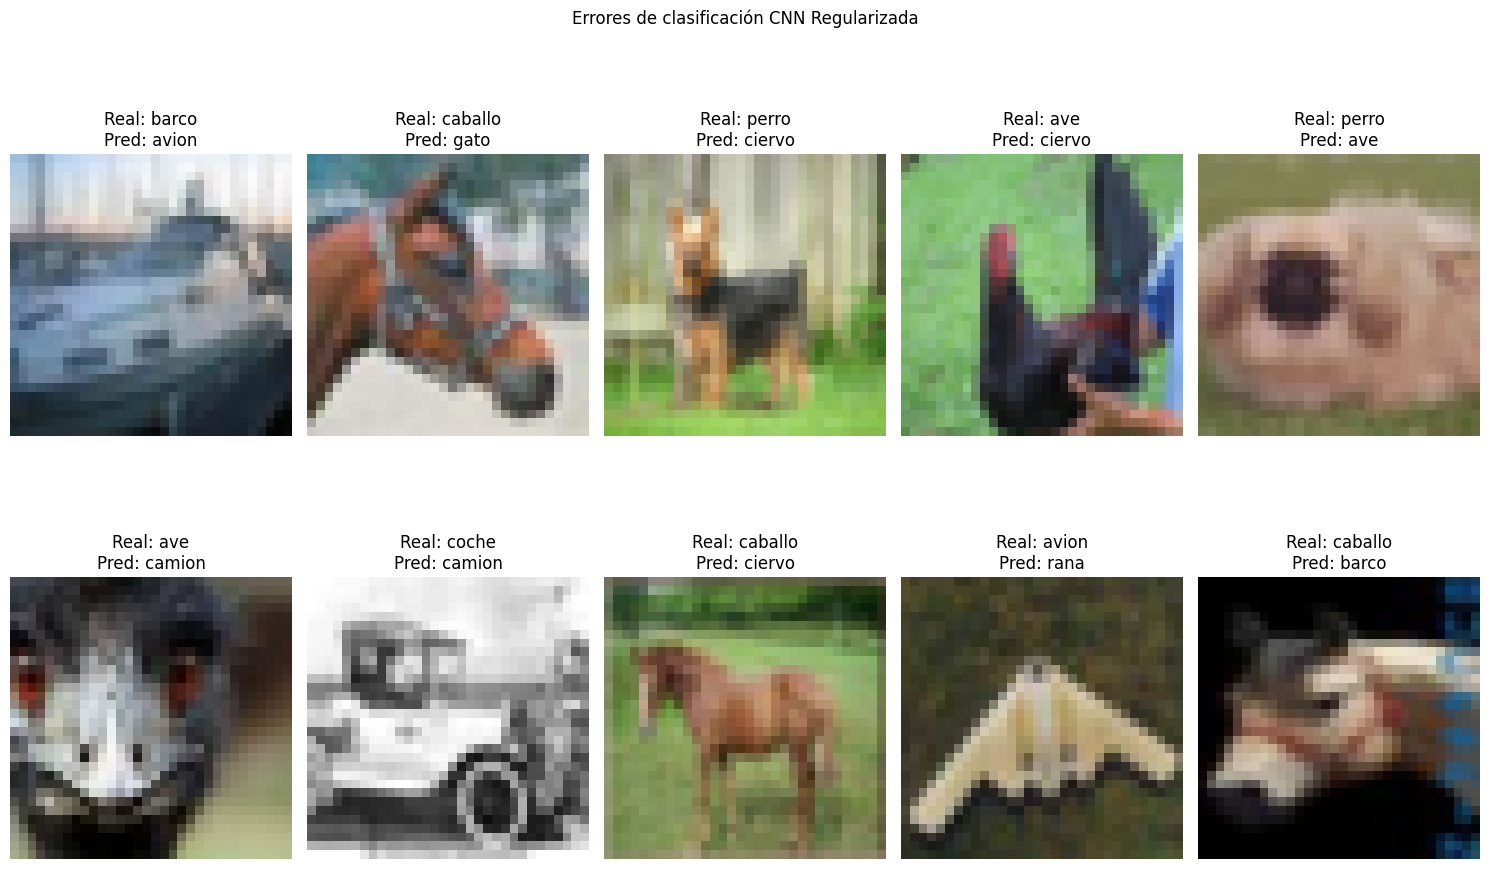

In [ ]:
errors_cnn_reg = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors_cnn_reg[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx])

    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred[idx]]

    plt.title(f"Real: {true_label}\nPred: {pred_label}")

    plt.axis("off")

plt.suptitle("Errores de clasificación CNN Regularizada")
plt.tight_layout()

plt.show()

### La comparación entre arquitecturas muestra una mejora progresiva del rendimiento a medida que se incorporan mecanismos más adecuados para el procesamiento de imágenes.

### El modelo fully connected obtiene el menor rendimiento debido a la pérdida de información espacial provocada por la operación de flattening. Posteriormente, la CNN base logra una mejora considerable gracias a la capacidad de las convoluciones para capturar patrones espaciales locales.

### Finalmente, la CNN regularizada alcanza el mejor resultado sobre el conjunto de test, evidenciando el impacto positivo de Batch Normalization y Dropout sobre la estabilidad del entrenamiento y la capacidad de generalización del modelo.

In [72]:
comparison = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "CNN Base",
        "CNN Regularizada"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_cnn,
        test_accuracy_cnn_reg
    ]
})

comparison

,Modelo,Test Accuracy
0,Fully Connected,0.4879
1,CNN Base,0.6626
2,CNN Regularizada,0.7481


# **5. CNN Profunda**

## **5.1. Dimensión de los datos**

### La dimensionalidad de los datos se mantiene igual que en las arquitecturas convolucionales anteriores. Las imágenes conservan su representación original de 32x32 píxeles y 3 canales RGB.

### En esta fase, el objetivo principal será incrementar la profundidad de la red para evaluar el impacto de arquitecturas más complejas sobre la capacidad de aprendizaje y generalización del modelo.

## **5.2. Definición y entrenamiento del modelo**

### El incremento de profundidad permite aprender representaciones jerárquicas más complejas, mejorando la capacidad del modelo para distinguir patrones visuales difíciles presentes en CIFAR-10.

### A medida que disminuye la resolución espacial y aumenta la profundidad semántica, el modelo construye representaciones progresivamente más abstractas.


In [73]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
model_deep_cnn = Sequential([

    # =====================================================
    # Bloque convolucional 1
    # =====================================================

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Bloque convolucional 2
    # =====================================================

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Bloque convolucional 3
    # =====================================================

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Clasificador
    # =====================================================

    Flatten(),

    Dense(256, activation='relu'),

    BatchNormalization(),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

model_deep_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep_cnn.summary()

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

### El modelo profundo se entrenó utilizando la misma configuración experimental empleada en las arquitecturas anteriores. Esto permite realizar una comparación consistente y evaluar el impacto del aumento de profundidad sobre el rendimiento y la capacidad de generalización del modelo.

In [74]:
history_deep_cnn = model_deep_cnn.fit(
    x_train,
    y_train_one_hot,
    epochs=15,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.4473 - loss: 1.6513 - val_accuracy: 0.5811 - val_loss: 1.1950
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6119 - loss: 1.0951 - val_accuracy: 0.6464 - val_loss: 1.0019
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6801 - loss: 0.9077 - val_accuracy: 0.6464 - val_loss: 1.0720
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7124 - loss: 0.8170 - val_accuracy: 0.7407 - val_loss: 0.7318
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7369 - loss: 0.7524 - val_accuracy: 0.7391 - val_loss: 0.7677
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7606 - loss: 0.6918 - val_accuracy: 0.7810 - val_loss: 0.6289
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7740 - loss: 0.6442 - val_accuracy: 0.7825 - val_loss: 0.6227
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7861 - loss: 0.6126 - 

## **5.3. Análisis de resultados**

### La CNN profunda presenta una mejora adicional respecto a las arquitecturas anteriores, alcanzando métricas de entrenamiento y validación más elevadas.

### El incremento de profundidad permite aprender representaciones visuales más complejas y discriminativas, mejorando la capacidad del modelo para generalizar.

### Aunque todavía existe una ligera diferencia entre entrenamiento y validación, las curvas muestran un comportamiento estable y un sobreajuste moderado gracias al uso de Batch Normalization y Dropout.

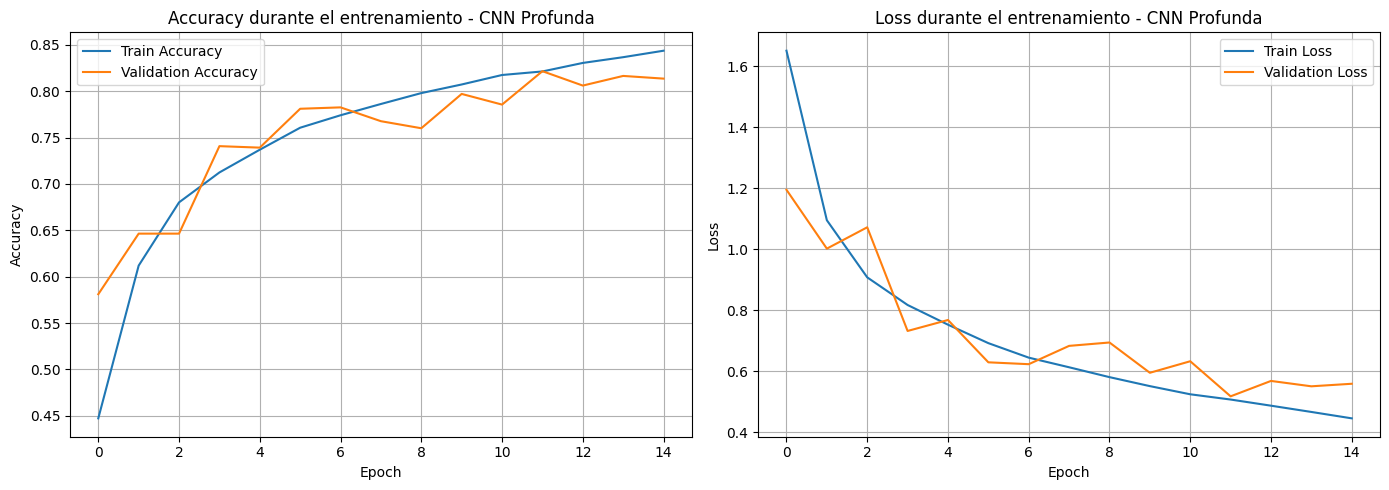

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_deep_cnn.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_deep_cnn.history['val_accuracy'], label='Validation Accuracy')

ax[0].set_title('Accuracy durante el entrenamiento - CNN Profunda')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')

ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_deep_cnn.history['loss'], label='Train Loss')
ax[1].plot(history_deep_cnn.history['val_loss'], label='Validation Loss')

ax[1].set_title('Loss durante el entrenamiento - CNN Profunda')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### La CNN profunda alcanza aproximadamente un 81% de accuracy sobre el conjunto de test, obteniendo el mejor rendimiento entre todas las arquitecturas evaluadas.


In [77]:
test_loss_deep_cnn, test_accuracy_deep_cnn = model_deep_cnn.evaluate(
    x_test,
    y_test_one_hot,
    verbose=0
)

# Tabla resumen
results_deep_cnn_df = pd.DataFrame({
    'Métrica': ['Test Loss', 'Test Accuracy'],
    'Valor': [test_loss_deep_cnn, test_accuracy_deep_cnn]
})

results_deep_cnn_df

,Métrica,Valor
0,Test Loss,0.578764
1,Test Accuracy,0.809300


### El classification report muestra una mejora significativa y mejor equilibrada entre todas las clases. Las categorías visualmente más diferenciables alcanzan métricas especialmente altas, mientras que las clases de animales continúan siendo las más complejas, aunque con un rendimiento claramente superior respecto a las arquitecturas anteriores.

In [78]:
from sklearn.metrics import classification_report
import numpy as np

# Predicciones del modelo
y_pred_probs = model_deep_cnn.predict(x_test)

# Convertir probabilidades a clases
y_pred = np.argmax(y_pred_probs, axis=1)

# Convertir etiquetas one-hot a clases
y_true = np.argmax(y_test_one_hot, axis=1)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=MAP_ELEMENTS.values()
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

       avion       0.87      0.79      0.83      1000
       coche       0.94      0.88      0.91      1000
         ave       0.81      0.68      0.74      1000
        gato       0.67      0.64      0.65      1000
      ciervo       0.75      0.81      0.78      1000
       perro       0.84      0.68      0.75      1000
        rana       0.67      0.95      0.79      1000
     caballo       0.90      0.83      0.86      1000
       barco       0.88      0.91      0.90      1000
      camion       0.85      0.92      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



### Se observa una mejora muy clara respecto a las arquitecturas anteriores, con una diagonal dominante y una reducción considerable de errores entre clases.


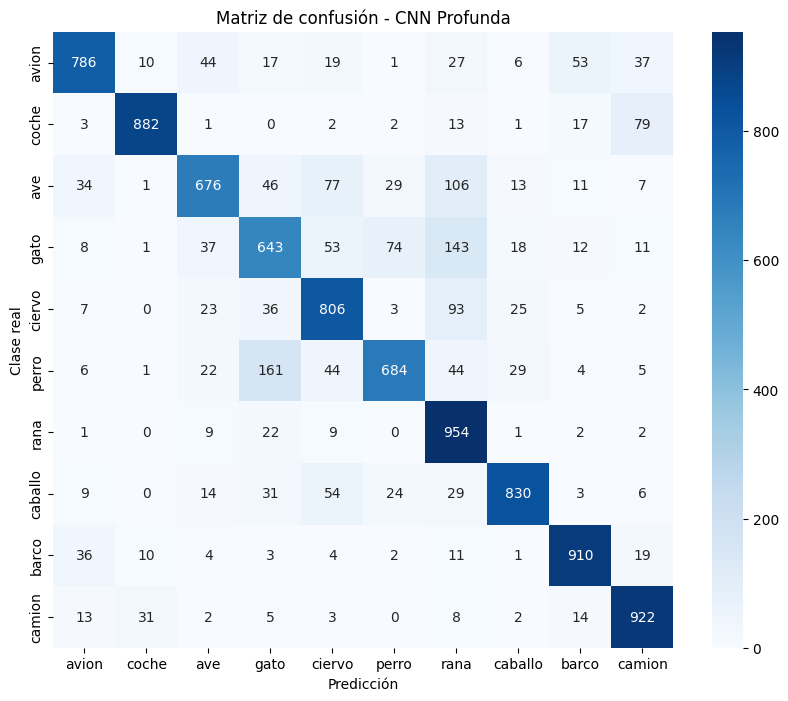

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualización
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=MAP_ELEMENTS.values(),
    yticklabels=MAP_ELEMENTS.values()
)

plt.title('Matriz de confusión - CNN Profunda')

plt.xlabel('Predicción')
plt.ylabel('Clase real')

plt.show()

### Ejemplo de imágenes incorrectamente clasificadas.

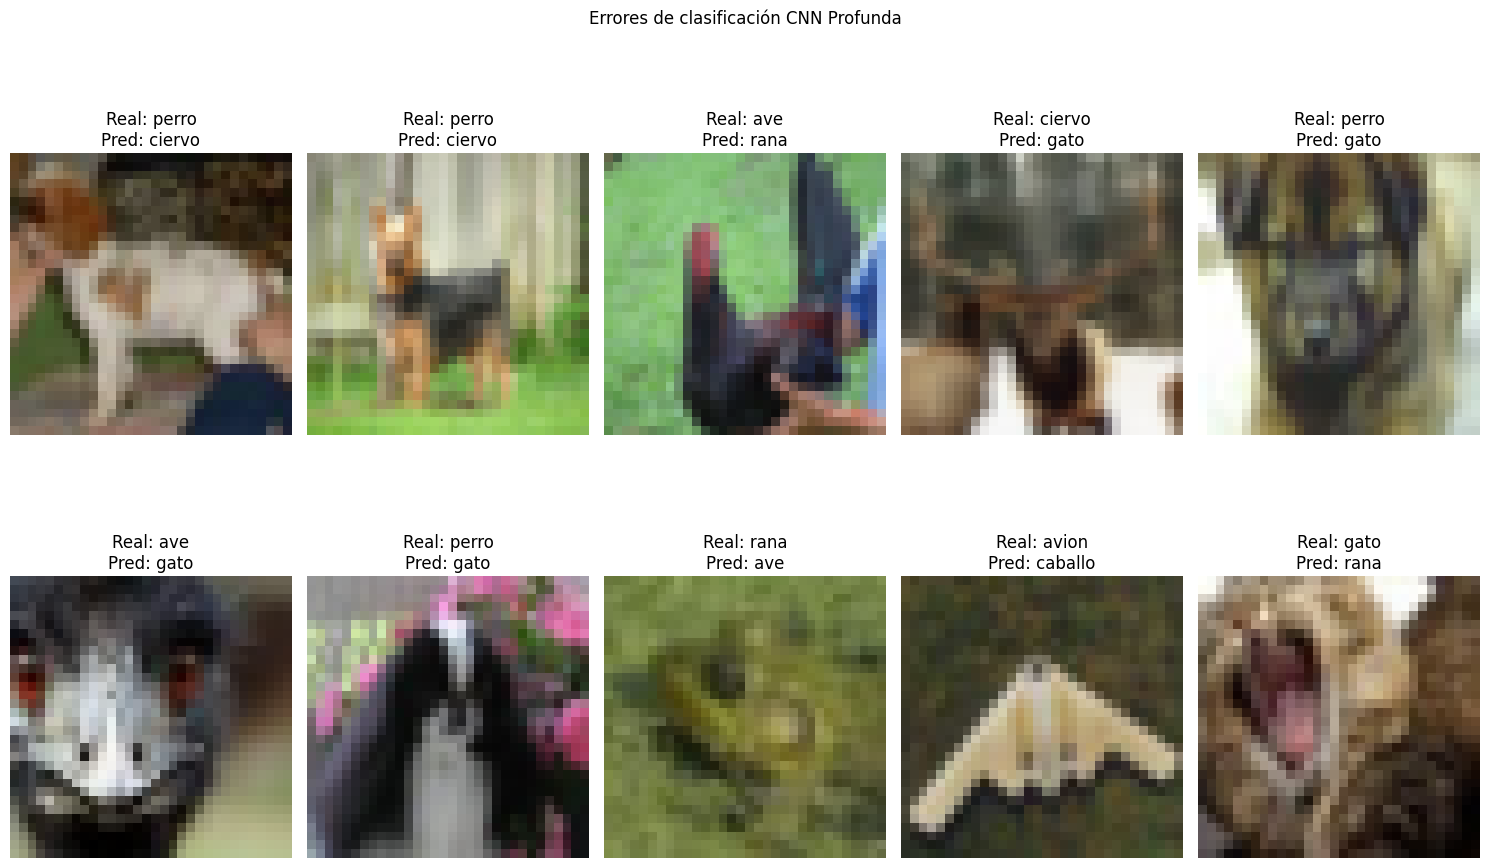

In [81]:
errors_deep_cnn = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors_deep_cnn[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx])

    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred[idx]]

    plt.title(f"Real: {true_label}\nPred: {pred_label}")

    plt.axis("off")

plt.suptitle("Errores de clasificación CNN Profunda")
plt.tight_layout()

plt.show()

### La comparación final muestra una mejora progresiva y consistente del rendimiento a medida que se incorporan arquitecturas convolucionales más profundas y técnicas de regularización.


In [83]:
comparison = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "CNN Base",
        "CNN Regularizada",
        "CNN Profunda"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_cnn,
        test_accuracy_cnn_reg,
        test_accuracy_deep_cnn
    ]
})

comparison

,Modelo,Test Accuracy
0,Fully Connected,0.4879
1,CNN Base,0.6626
2,CNN Regularizada,0.7481
3,CNN Profunda,0.8093


# **6. Data augmentation**

## **6.1. Dimensión de los datos**

### La dimensionalidad de los datos se mantiene sin cambios respecto a las arquitecturas convolucionales anteriores. Las imágenes continúan utilizando su representación original de 32x32 píxeles y 3 canales RGB.

### En esta fase, el objetivo principal será incrementar la variabilidad del conjunto de entrenamiento mediante técnicas de Data Augmentation para mejorar la capacidad de generalización del modelo.

## **6.2. Definición y entrenamiento del modelo**

### El Data Augmentation introduce transformaciones aleatorias sobre las imágenes de entrenamiento con el objetivo de aumentar artificialmente la diversidad del dataset. Esto permite que el modelo aprenda representaciones más robustas e invariantes frente a pequeñas variaciones espaciales y geométricas.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)


### A continuación se muestran algunos ejemplos de imágenes generadas mediante Data Augmentation.

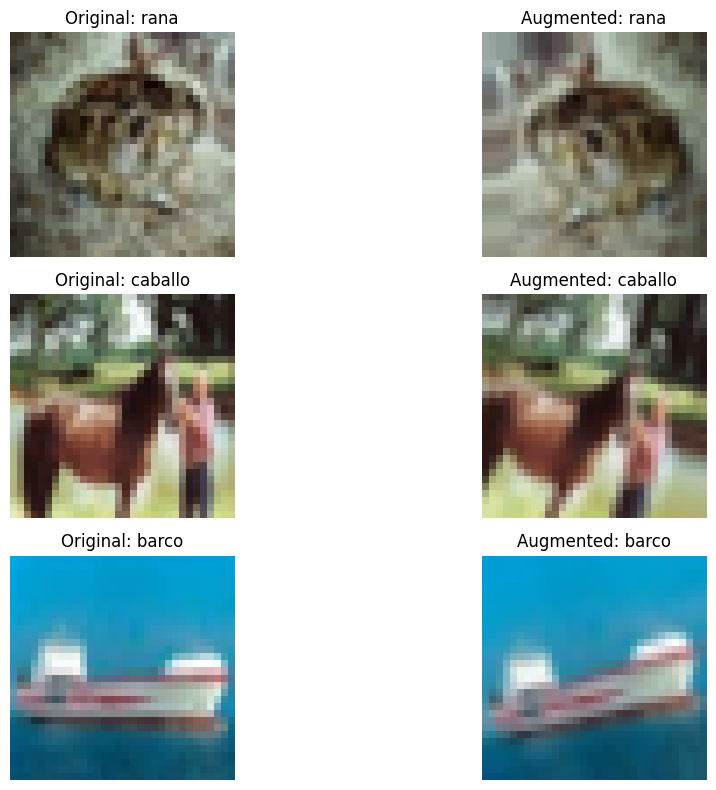

In [88]:
plt.figure(figsize=(12,8))

# Seleccionar 3 imágenes originales
sample_images = x_train[:3]
sample_labels = y_train_one_hot[:3]

# Generar augmentation
augmented_images = next(
    datagen.flow(
        sample_images,
        sample_labels,
        batch_size=3,
        shuffle=False
    )
)[0]

for i in range(3):

    # Imagen original
    plt.subplot(3,2,2*i+1)

    plt.imshow(sample_images[i])

    label = MAP_ELEMENTS[np.argmax(sample_labels[i])]

    plt.title(f"Original: {label}")

    plt.axis('off')

    # Imagen aumentada
    plt.subplot(3,2,2*i+2)

    plt.imshow(augmented_images[i])

    plt.title(f"Augmented: {label}")

    plt.axis('off')

plt.tight_layout()

plt.show()

### El modelo es entrenado utilizando Data Augmentation, permite evaluar de forma justa el impacto de estas transformaciones sobre la capacidad de generalización de la CNN profunda.

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# ============================================================
# CNN Profunda + Data Augmentation
# ============================================================

model_aug = Sequential([

    # =====================================================
    # Bloque convolucional 1
    # =====================================================

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Bloque convolucional 2
    # =====================================================

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Bloque convolucional 3
    # =====================================================

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # =====================================================
    # Clasificador
    # =====================================================

    Flatten(),

    Dense(256, activation='relu'),

    BatchNormalization(),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

# ============================================================
# Compilación
# ============================================================

model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Entrenamiento con Data Augmentation
# ============================================================

history_aug = model_aug.fit(

    datagen.flow(
        x_train,
        y_train_one_hot,
        batch_size=64
    ),

    epochs=15,

    validation_data=(
        x_valid,
        y_valid_one_hot
    )
)

/Users/josejp/Documents/2026/UNIR/Cuatrimestre_2/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.4034 - loss: 1.7852 - val_accuracy: 0.4990 - val_loss: 1.3934
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.5602 - loss: 1.2375 - val_accuracy: 0.4445 - val_loss: 1.7062
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6176 - loss: 1.0743 - val_accuracy: 0.6599 - val_loss: 0.9856
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.6549 - loss: 0.9821 - val_accuracy: 0.6743 - val_loss: 0.9487
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.6790 - loss: 0.9184 - val_accuracy: 0.6765 - val_loss: 0.9378
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.6936 - loss: 0.8685 - val_accuracy: 0.6970 - val_loss: 0.8913
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7092 - loss: 0.8385 - val_accuracy: 0.6127 - val_loss: 1.2816
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7128 - loss: 0.8145 - 

## **6.3. Análisis de resultados**

### El entrenamiento con Data Augmentation presenta mayores fluctuaciones en las curvas de validación debido a la variabilidad introducida artificialmente sobre las imágenes de entrenamiento.

### El modelo mantiene una tendencia general estable y logra una buena capacidad de generalización, reduciendo el sobreajuste y mejorando la robustez frente a variaciones espaciales y geométricas.

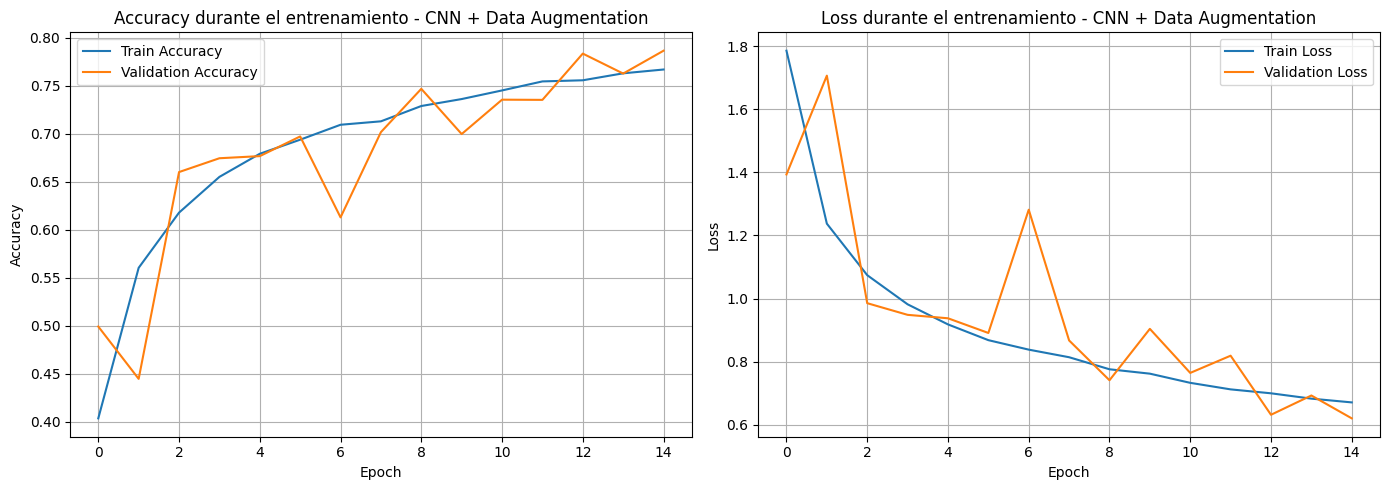

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_aug.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_aug.history['val_accuracy'], label='Validation Accuracy')

ax[0].set_title('Accuracy durante el entrenamiento - CNN + Data Augmentation')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')

ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_aug.history['loss'], label='Train Loss')
ax[1].plot(history_aug.history['val_loss'], label='Validation Loss')

ax[1].set_title('Loss durante el entrenamiento - CNN + Data Augmentation')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Este modelo alcanza aproximadamente un 79% de accuracy sobre el conjunto de test, manteniendo un rendimiento alto y una buena capacidad de generalización.

In [91]:
test_loss_aug, test_accuracy_aug = model_aug.evaluate(
    x_test,
    y_test_one_hot,
    verbose=0
)

# Tabla resumen
results_aug_df = pd.DataFrame({
    'Métrica': ['Test Loss', 'Test Accuracy'],
    'Valor': [test_loss_aug, test_accuracy_aug]
})

results_aug_df

,Métrica,Valor
0,Test Loss,0.635293
1,Test Accuracy,0.789600


### El classification report muestra un rendimiento elevado y equilibrado entre la mayoría de las clases.

In [93]:
from sklearn.metrics import classification_report
import numpy as np

# Predicciones del modelo
y_pred_probs = model_aug.predict(x_test)

# Convertir probabilidades a clases
y_pred = np.argmax(y_pred_probs, axis=1)

# Convertir etiquetas one-hot a clases
y_true = np.argmax(y_test_one_hot, axis=1)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=MAP_ELEMENTS.values()
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

       avion       0.73      0.88      0.80      1000
       coche       0.93      0.90      0.91      1000
         ave       0.77      0.67      0.71      1000
        gato       0.79      0.45      0.58      1000
      ciervo       0.68      0.90      0.77      1000
       perro       0.85      0.56      0.67      1000
        rana       0.70      0.92      0.80      1000
     caballo       0.80      0.86      0.83      1000
       barco       0.93      0.84      0.88      1000
      camion       0.82      0.91      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.78     10000
weighted avg       0.80      0.79      0.78     10000



### La matriz de confusión muestra una diagonal dominante y una reducción importante de errores entre clases, evidenciando la capacidad de generalización.

### Aunque persisten algunas confusiones entre animales visualmente similares, el modelo logra clasificaciones mucho más robustas gracias al uso de Data Augmentation.

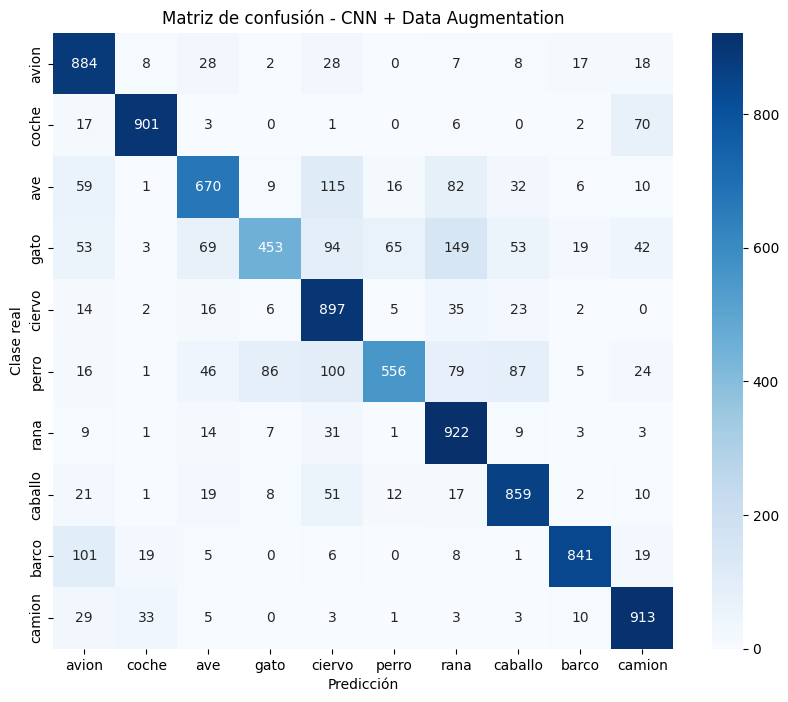

In [94]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualización
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=MAP_ELEMENTS.values(),
    yticklabels=MAP_ELEMENTS.values()
)

plt.title('Matriz de confusión - CNN + Data Augmentation')

plt.xlabel('Predicción')
plt.ylabel('Clase real')

plt.show()

### Ejemplo de imágenes incorrectamente clasificadas.

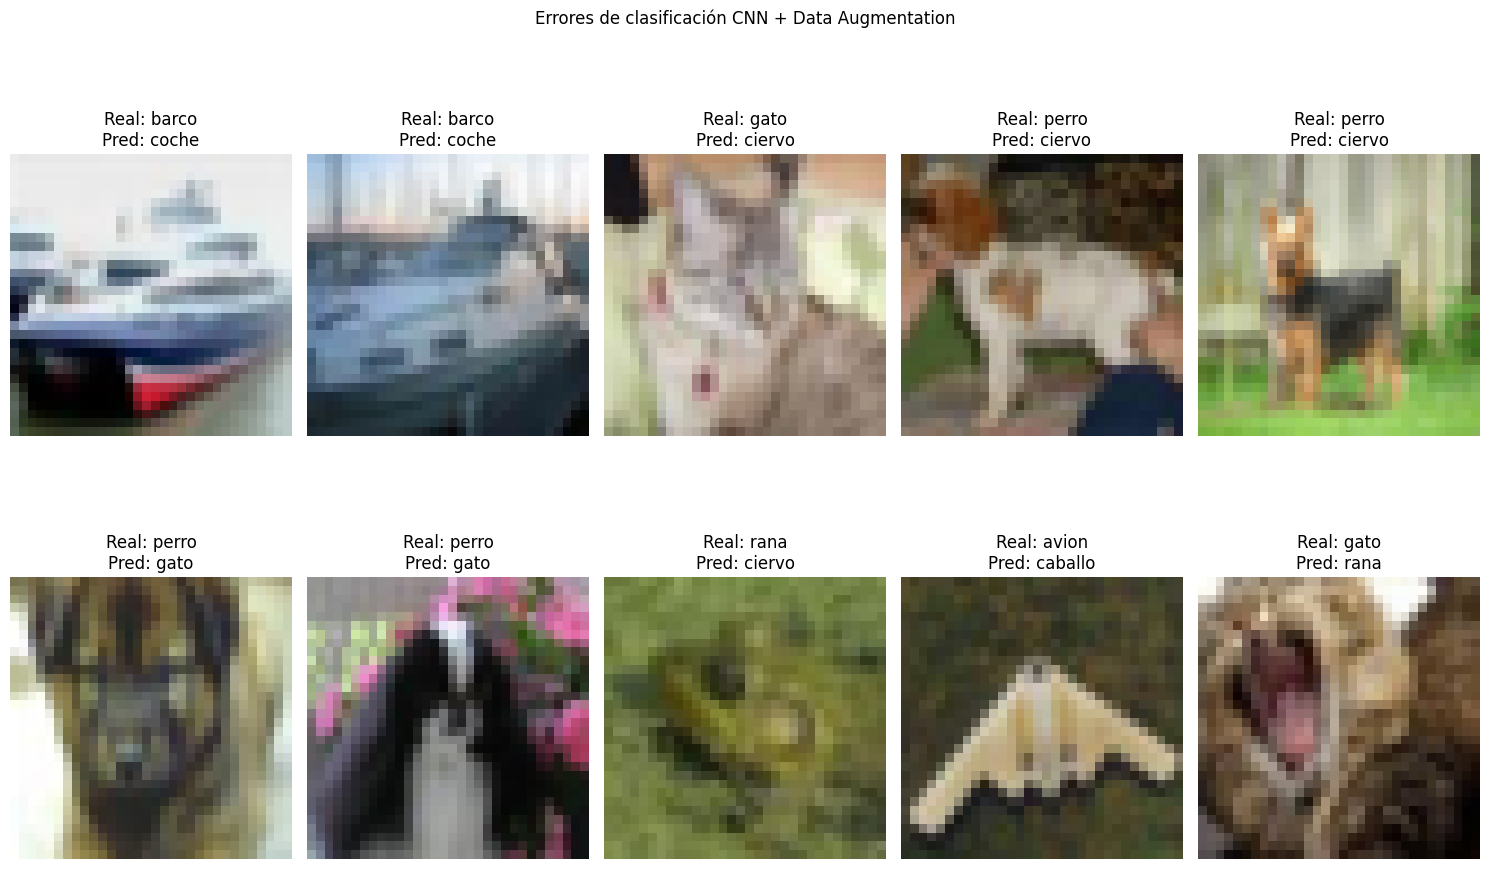

In [95]:
errors_aug = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(errors_aug[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx])

    true_label = MAP_ELEMENTS[y_true[idx]]
    pred_label = MAP_ELEMENTS[y_pred[idx]]

    plt.title(f"Real: {true_label}\nPred: {pred_label}")

    plt.axis("off")

plt.suptitle("Errores de clasificación CNN + Data Augmentation")
plt.tight_layout()

plt.show()

### La CNN profunda obtiene el mejor resultado global sobre el conjunto de test, mientras que el uso de Data Augmentation permite mantener un rendimiento competitivo y mejorar la robustez del modelo frente a variaciones espaciales y geométricas.

In [97]:
comparison = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "CNN Base",
        "CNN Regularizada",
        "CNN Profunda",
        "CNN + Data Augmentation"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_cnn,
        test_accuracy_cnn_reg,
        test_accuracy_deep_cnn,
        test_accuracy_aug
    ]
})

comparison

,Modelo,Test Accuracy
0,Fully Connected,0.4879
1,CNN Base,0.6626
2,CNN Regularizada,0.7481
3,CNN Profunda,0.8093
4,CNN + Data Augmentation,0.7896


# **7. Conclusiones finales**

### A lo largo del trabajo se observó una mejora progresiva del rendimiento a medida que se incorporaron arquitecturas más elabora para el procesamiento de imágenes.

### El modelo fully connected presentó importantes limitaciones debido a la pérdida de información espacial provocada por la operación de flattening obteniendo el menor rendimiento sobre el conjunto de test.

### La incorporación de capas convolucionales permitió capturar patrones espaciales locales y aprender representaciones jerárquicas más complejas produciendo mejoras muy significativas en capacidad de generalización y precisión.

### El uso de Batch Normalization y Dropout contribuyó a estabilizar el entrenamiento y reducir el sobreajuste, mejorando aún más el rendimiento del modelo.

### Finalmente, el incremento de profundidad de la CNN permitió alcanzar el mejor resultado global, evidenciando que arquitecturas más profundas son capaces de aprender características visuales más discriminativas.

### Si embargo, el uso de Data Augmentation permitió aumentar artificialmente la variabilidad del dataset, favoreciendo modelos más robustos frente a pequeñas transformaciones espaciales.

### En general, los resultados obtenidos confirman que las redes convolucionales profundas representan una solución mucho más adecuada que las arquitecturas densas tradicionales para tareas de clasificación de imágenes como CIFAR-10.

# **8. Uso de la IA en la Actividad**

### En este trabajo he empleado ChatGPT como herramienta de apoyo para resolver dudas, debatir propuestas y realizar consultas relacionadas con modelos, librerías y conceptos teóricos vinculados al aprendizaje profundo y las Redes Neuronales Convolucionales. Asimismo, he recurrido a otras fuentes en internet, como videos de YouTube, que me permitieron reforzar y visualizar mejor algunos conceptos.

### El uso del chatbot se ha centrado principalmente en consultas específicas y apoyo conceptual durante el desarrollo de la actividad. Además, antes de iniciar las interacciones, se definió el rol, el contexto y el estilo esperado de las respuestas con el objetivo de obtener una asistencia más precisa y alineada con el trabajo realizado.

### En conclusión, el uso de herramientas de inteligencia artificial ha resultado útil para agilizar el proceso de investigación, organizar conceptos y orientar la búsqueda de información complementaria en fuentes oficiales, como documentación técnica y recursos especializados.